In [1]:
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):
  def __init__(self, layers):
    super().__init__()
    modules = []
    for i in range(len(layers) - 1):
        modules.append(nn.Linear(layers[i], layers[i+1]))
        if i < len(layers) - 2:
            modules.append(nn.Tanh())
    self.net = nn.Sequential(*modules)

  def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        outputs = self.net(inputs)
        u = outputs[:, 0:1]
        v = outputs[:, 1:2]
        p = outputs[:, 2:3]
        return u, v, p

In [3]:
def compute_grad(output, input):
  return torch.autograd.grad(output, input, grad_outputs=torch.ones_like(output),create_graph=True,retain_graph=True)[0]

In [4]:
N_interior = 10000
N_boundary = 1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# these would be my interior points
x_int = torch.rand((N_interior, 1), requires_grad=True).to(device)
y_int = torch.rand((N_interior, 1), requires_grad=True).to(device)

''' top wall boundary points, to avoid any corner singularities these are starting
from .01 and ending at 0.99'''
x_top = torch.empty(N_boundary, 1).uniform_(0.01, 0.99).to(device)
y_top = torch.ones((N_boundary, 1)).to(device)

# boundary points for the bottom wall
x_bot = torch.rand((N_boundary, 1)).to(device)
y_bot = torch.zeros((N_boundary, 1)).to(device)

# boundary poitns for the left wall
x_left = torch.zeros((N_boundary, 1)).to(device)
y_left = torch.rand((N_boundary, 1)).to(device)

# for the right wall
x_right = torch.ones((N_boundary, 1)).to(device)
y_right = torch.rand((N_boundary, 1)).to(device)

# Pressure reference point, simply my centre of gravity
x_pref = torch.tensor([[0.5]], requires_grad=True).to(device)
y_pref = torch.tensor([[0.5]], requires_grad=True).to(device)

Re = 100
pinn_layers = [2, 50, 50, 50, 50, 50, 3]
model = PINN(pinn_layers)
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
mse_loss = nn.MSELoss()

In [5]:
def calculate_loss():
    # first are the boundary losses
    # Top wall with u=1 and v=0
    u_top, v_top, _ = model(x_top, y_top)
    loss_top = mse_loss(u_top, torch.ones_like(u_top)) + mse_loss(v_top, torch.zeros_like(v_top))

    # Bottom, Left, and Right walls with no slip and zero velocity
    u_bot, v_bot, _ = model(x_bot, y_bot)
    u_left, v_left, _ = model(x_left, y_left)
    u_right, v_right, _ = model(x_right, y_right)

    loss_walls = (mse_loss(u_bot, torch.zeros_like(u_bot)) + mse_loss(v_bot, torch.zeros_like(v_bot)) +
                  mse_loss(u_left, torch.zeros_like(u_left)) + mse_loss(v_left, torch.zeros_like(v_left)) +
                  mse_loss(u_right, torch.zeros_like(u_right)) + mse_loss(v_right, torch.zeros_like(v_right)))

    # Pressure reference loss, with pressure of 0 at the centre
    _, _, p_ref = model(x_pref, y_pref)
    loss_pref = mse_loss(p_ref, torch.zeros_like(p_ref))

    # physics loss
    u_int, v_int, p_int = model(x_int, y_int)

    # derivatives
    u_x = compute_grad(u_int, x_int)
    u_y = compute_grad(u_int, y_int)
    v_x = compute_grad(v_int, x_int)
    v_y = compute_grad(v_int, y_int)
    p_x = compute_grad(p_int, x_int)
    p_y = compute_grad(p_int, y_int)
    u_xx = compute_grad(u_x, x_int)
    u_yy = compute_grad(u_y, y_int)
    v_xx = compute_grad(v_x, x_int)
    v_yy = compute_grad(v_y, y_int)

    # Residuals for continuity and navier stokes equation
    f_c = u_x + v_y
    f_u = u_int * u_x + v_int * u_y + p_x - (1/Re) * (u_xx + u_yy)
    f_v = u_int * v_x + v_int * v_y + p_y - (1/Re) * (v_xx + v_yy)

    loss_pde = mse_loss(f_c, torch.zeros_like(f_c)) + \
               mse_loss(f_u, torch.zeros_like(f_u)) + \
               mse_loss(f_v, torch.zeros_like(f_v))

    # Total Loss
    total_loss = loss_top + loss_walls + loss_pref + 10*loss_pde
    return total_loss

#Training loop
epochs = 6000

torch.set_grad_enabled(True)

#i'd run adam optimizer for first 5000 iterations, and lbfgs for the remaining
optimizer_adam = torch.optim.Adam(model.parameters(), lr = 1e-3)
for epoch in range(5000):
    optimizer_adam.zero_grad()
    loss = calculate_loss()
    loss.backward()
    optimizer_adam.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Total Loss: {loss.item():.6f}")



optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr = 1)

def closure():
    optimizer_lbfgs.zero_grad()
    loss = calculate_loss()
    loss.backward()
    return loss

for epoch in range(5000, epochs,1):
    loss = optimizer_lbfgs.step(closure)
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Total Loss: {loss.item():.6f}")

print("Training Complete. The PINN is now a surrogate model for the cavity flow.")

Epoch 0 | Total Loss: 0.916030
Epoch 500 | Total Loss: 0.081414
Epoch 1000 | Total Loss: 0.073900
Epoch 1500 | Total Loss: 0.067994
Epoch 2000 | Total Loss: 0.065621
Epoch 2500 | Total Loss: 0.063648
Epoch 3000 | Total Loss: 0.066740
Epoch 3500 | Total Loss: 0.071214
Epoch 4000 | Total Loss: 0.063377
Epoch 4500 | Total Loss: 0.058120
Epoch 5000 | Total Loss: 0.054783
Epoch 5500 | Total Loss: 0.001307
Training Complete. The PINN is now a surrogate model for the cavity flow.


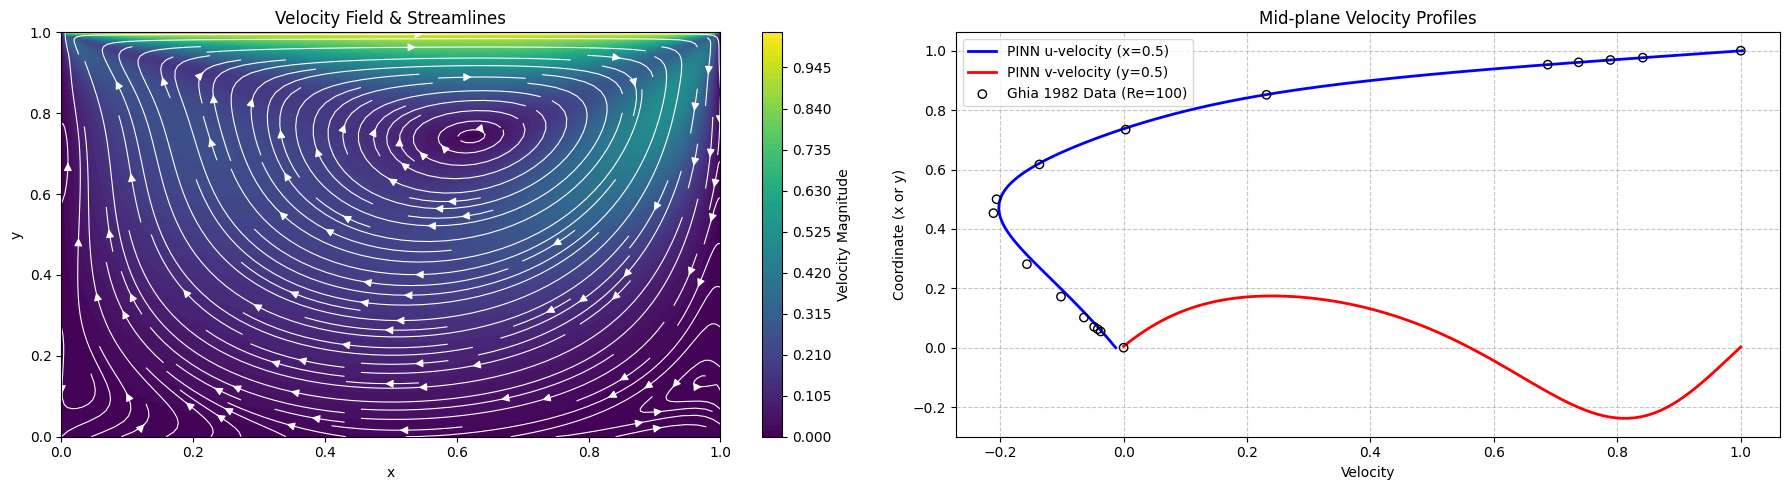

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resolution = 100
x_plot = np.linspace(0, 1, resolution)
y_plot = np.linspace(0, 1, resolution)
X, Y = np.meshgrid(x_plot, y_plot)

# just flattening grid and converting to pytorch tensors
x_tensor = torch.tensor(X.flatten()[:, None], dtype=torch.float32).to(device)
y_tensor = torch.tensor(Y.flatten()[:, None], dtype=torch.float32).to(device)


# converting output tensors to numpy and reshaping to 2d grid
U = u_pred.cpu().numpy().reshape(resolution, resolution)
V = v_pred.cpu().numpy().reshape(resolution, resolution)
P = p_pred.cpu().numpy().reshape(resolution, resolution)
Velocity_Mag = np.sqrt(U**2 + V**2)

# defining the Ghia 1982 Reference Data (Re=100) which give the u velocity component at y axis at midpoitn
y_ghia = np.array([
    1.0000, 0.9766, 0.9688, 0.9609, 0.9531, 0.8516, 0.7344, 0.6172,
    0.5000, 0.4531, 0.2813, 0.1719, 0.1016, 0.0703, 0.0625, 0.0547, 0.0000
])

u_ghia_100 = np.array([
    1.00000, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332, -0.13641,
   -0.20581, -0.21090, -0.15662, -0.10150, -0.06434, -0.04775, -0.04192, -0.03717, 0.00000
])
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# plot 1, simple velocity streamplot
ax = axes[0]
cf1 = ax.contourf(X, Y, Velocity_Mag, levels=100, cmap='viridis')
fig.colorbar(cf1, ax=ax, label='Velocity Magnitude')
ax.streamplot(X, Y, U, V, color='white', density=1.5, linewidth=0.8, arrowsize=1.2)
ax.set_title("Velocity Field & Streamlines")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)


# plot 2, comparison with ghia data
ax = axes[1]
mid_idx = resolution // 2
ax.plot(U[:, mid_idx], y_plot, label='PINN u-velocity (x=0.5)', color='blue', linewidth=2)
ax.plot(x_plot, V[mid_idx, :], label='PINN v-velocity (y=0.5)', color='red', linewidth=2)

ax.scatter(u_ghia_100, y_ghia, color='black', marker='o', facecolors='none',
           label='Ghia 1982 Data (Re=100)', zorder=5)

ax.set_title("Mid-plane Velocity Profiles")
ax.set_xlabel("Velocity")
ax.set_ylabel("Coordinate (x or y)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()